<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/02_clusterizacao_com_despesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importa os arquivos salvos no diretório do Github

!git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
%cd /content/mineracao-dados-eleitorais-2026

!ls dados

Cloning into 'mineracao-dados-eleitorais-2026'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 82 (delta 21), reused 12 (delta 12), pack-reused 45 (from 1)
Receiving objects: 100% (82/82), 30.24 MiB | 17.63 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/mineracao-dados-eleitorais-2026
 bem_candidato_2026.zip
'candidatos_DEPUTADO_FEDERAL_['\''PR'\'', '\''RS'\'', '\''SC'\'']_2026.csv'
 consulta_cand_2026.zip
 prestacao_de_contas_eleitorais_candidatos_2026.zip


In [3]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np

# =========================
# 1. Caminhos dos arquivos
# =========================
PASTA_DADOS = Path("dados")
PASTA_EXTRAIDOS = PASTA_DADOS / "extraidos_despesas"

ARQUIVO_CANDIDATOS = (
    PASTA_DADOS / "candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv"
)

ARQUIVO_ZIP = (
    PASTA_DADOS / "prestacao_de_contas_eleitorais_candidatos_2026.zip"
)

ARQUIVO_SAIDA = (
    PASTA_DADOS / "candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

ESTADOS = ["PR", "RS", "SC"]

# =============================================
# 2. Lê a base principal dos candidatos
# =============================================
candidatos = pd.read_csv(
    ARQUIVO_CANDIDATOS,
    sep=",",
    dtype={"SQ_CANDIDATO": "string"},
    low_memory=False
)

candidatos = candidatos[
    candidatos["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
].copy()

# =========================================================
# 3. Localiza e descompacta somente os CSVs necessários
# =========================================================
PASTA_EXTRAIDOS.mkdir(parents=True, exist_ok=True)

arquivos_esperados = {
    f"despesas_contratadas_candidatos_2026_{uf}.csv".lower()
    for uf in ESTADOS
}

with ZipFile(ARQUIVO_ZIP, "r") as zip_ref:
    arquivos_selecionados = [
        arquivo
        for arquivo in zip_ref.namelist()
        if Path(arquivo).name.lower() in arquivos_esperados
    ]

    if len(arquivos_selecionados) != len(ESTADOS):
        raise FileNotFoundError(
            "Não encontrei os arquivos de despesas contratadas "
            "de PR, RS e SC dentro do ZIP."
        )

    arquivos_extraidos = [
        Path(zip_ref.extract(arquivo, PASTA_EXTRAIDOS))
        for arquivo in arquivos_selecionados
    ]

# =====================================================================
# 4. Processa os arquivos grandes em partes e soma por candidato
# =====================================================================
parciais = []

for arquivo in arquivos_extraidos:
    print(f"Processando: {arquivo.name}")

    leitor = pd.read_csv(
        arquivo,
        sep=";",
        encoding="latin1",
        usecols=[
            "DS_CARGO",
            "SQ_CANDIDATO",
            "SQ_DESPESA",
            "VR_DESPESA_CONTRATADA"
        ],
        dtype={
            "DS_CARGO": "string",
            "SQ_CANDIDATO": "string",
            "SQ_DESPESA": "string",
            "VR_DESPESA_CONTRATADA": "string"
        },
        chunksize=200_000,
        low_memory=False
    )

    for parte in leitor:
        parte = parte[
            parte["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
        ].copy()

        parte["VR_DESPESA_CONTRATADA"] = pd.to_numeric(
            parte["VR_DESPESA_CONTRATADA"]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).fillna(0)

        parcial = (
            parte
            .groupby("SQ_CANDIDATO", as_index=False)
            .agg(
                Total_Gasto_Campanha=(
                    "VR_DESPESA_CONTRATADA", "sum"
                ),
                QTD_DESPESAS_CONTRATADAS=(
                    "SQ_DESPESA", "count"
                )
            )
        )

        parciais.append(parcial)

# Consolida PR, RS e SC
totais_despesas = (
    pd.concat(parciais, ignore_index=True)
    .groupby("SQ_CANDIDATO", as_index=False)
    .agg(
        Total_Gasto_Campanha=(
            "Total_Gasto_Campanha", "sum"
        ),
        QTD_DESPESAS_CONTRATADAS=(
            "QTD_DESPESAS_CONTRATADAS", "sum"
        )
    )
)

# =====================================================
# 5. Une os gastos ao arquivo principal de candidatos
# =====================================================
resultado = candidatos.merge(
    totais_despesas,
    on="SQ_CANDIDATO",
    how="left"
)

resultado["TEM_DESPESA_CONTRATADA"] = (
    resultado["Total_Gasto_Campanha"].notna()
)

resultado["Total_Gasto_Campanha"] = (
    resultado["Total_Gasto_Campanha"].fillna(0)
)

resultado["QTD_DESPESAS_CONTRATADAS"] = (
    resultado["QTD_DESPESAS_CONTRATADAS"].fillna(0).astype(int)
)

# Nova variável com transformação logarítmica
resultado["Total_Gasto_Campanha_Log"] = np.log1p(
    resultado["Total_Gasto_Campanha"]
)

# ======================================
# 6. Gera o CSV para as novas análises
# ======================================
resultado.to_csv(
    ARQUIVO_SAIDA,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo criado: {ARQUIVO_SAIDA}")
display(
    resultado[
        [
            "SG_UF",
            "NM_CANDIDATO",
            "Total_Gasto_Campanha",
            "Total_Gasto_Campanha_Log",
            "QTD_DESPESAS_CONTRATADAS"
        ]
    ].head()
)

Processando: despesas_contratadas_candidatos_2026_PR.csv
Processando: despesas_contratadas_candidatos_2026_RS.csv
Processando: despesas_contratadas_candidatos_2026_SC.csv
Arquivo criado: dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv


,SG_UF,NM_CANDIDATO,Total_Gasto_Campanha,Total_Gasto_Campanha_Log,QTD_DESPESAS_CONTRATADAS
0,PR,MARIO SETO TAKEGUMA JUNIOR,34140.0,10.438254,16
1,PR,ANTÔNIO FERNANDO TEIGAO,59862.86,10.999828,35
2,PR,CAMILLA DE MORAES GONDA,283738.41,12.555812,59
3,PR,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,0.0,0.0,1
4,PR,OMAR RAIMUNDO PICHETH NETO,144017.53,11.877697,48


Candidatos sem correspondência de escolaridade: 0
Registros utilizados na análise: 1,117


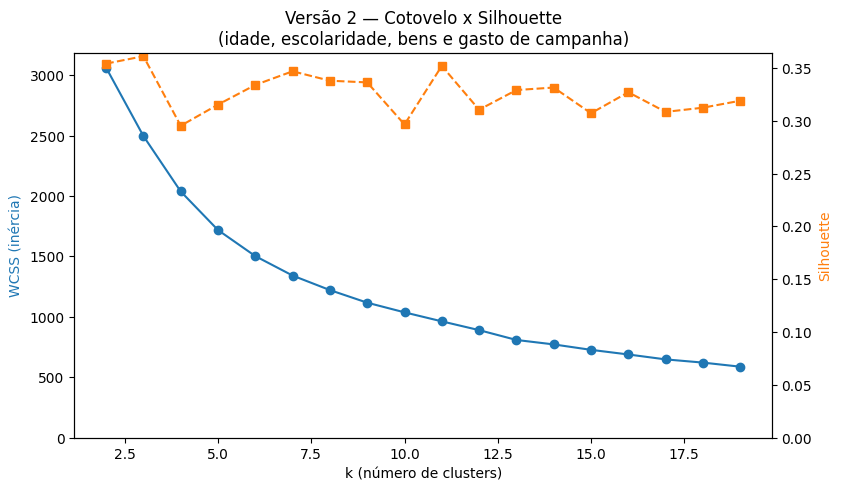

,k,WCSS,Silhouette
0,2,3062.103436,0.354206
1,3,2496.535013,0.361250
2,4,2037.956545,0.295375
3,5,1718.380490,0.315409
4,6,1502.773229,0.334056
5,7,1341.770642,0.346961
6,8,1221.716148,0.338039
7,9,1117.419772,0.336439
8,10,1037.491754,0.296613
9,11,962.996813,0.352052


k=2 | WCSS=3062.103 | silhouette=0.354
k=3 | WCSS=2496.535 | silhouette=0.361
k=4 | WCSS=2037.957 | silhouette=0.295
k=5 | WCSS=1718.380 | silhouette=0.315
k=6 | WCSS=1502.773 | silhouette=0.334
k=7 | WCSS=1341.771 | silhouette=0.347
k=8 | WCSS=1221.716 | silhouette=0.338
k=9 | WCSS=1117.420 | silhouette=0.336
k=10 | WCSS=1037.492 | silhouette=0.297
k=11 | WCSS=962.997 | silhouette=0.352
k=12 | WCSS=890.348 | silhouette=0.311
k=13 | WCSS=808.968 | silhouette=0.329
k=14 | WCSS=772.115 | silhouette=0.332
k=15 | WCSS=727.239 | silhouette=0.307
k=16 | WCSS=688.865 | silhouette=0.327
k=17 | WCSS=648.219 | silhouette=0.309
k=18 | WCSS=621.673 | silhouette=0.312
k=19 | WCSS=587.833 | silhouette=0.319


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEMENTE = 42

# Arquivo gerado na etapa anterior
ARQUIVO_DADOS = Path(
    "dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

# Carrega a base
df = pd.read_csv(
    ARQUIVO_DADOS,
    encoding="utf-8-sig",
    low_memory=False
)

# Converte escolaridade em anos de estudo
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}

df["ANOS_ESTUDO"] = (
    df["DS_GRAU_INSTRUCAO"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(ANOS_ESTUDO_POR_GRAU)
)

print(
    "Candidatos sem correspondência de escolaridade:",
    df["ANOS_ESTUDO"].isna().sum()
)

# Variáveis da nova análise
variaveis_v2 = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

# Remove registros sem informação suficiente para a clusterização
dados_v2 = (
    df[variaveis_v2]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Registros utilizados na análise: {len(dados_v2):,}")

# Padroniza as variáveis
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(dados_v2)

# Testa valores de k entre 2 e 19
wcss_v2, sil_v2 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(
        n_clusters=k,
        random_state=SEMENTE,
        n_init=10
    )

    labels = km.fit_predict(X_v2)

    wcss_v2.append(km.inertia_)
    sil_v2.append(silhouette_score(X_v2, labels))

# Gráfico de cotovelo e silhouette
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    list(faixa_k),
    wcss_v2,
    marker="o",
    color="tab:blue"
)

ax1.set_xlabel("k (número de clusters)")
ax1.set_ylabel("WCSS (inércia)", color="tab:blue")
ax1.set_ylim(bottom=0)
ax1.set_title(
    "Versão 2 — Cotovelo x Silhouette\n"
    "(idade, escolaridade, bens e gasto de campanha)"
)

ax2 = ax1.twinx()

ax2.plot(
    list(faixa_k),
    sil_v2,
    marker="s",
    linestyle="--",
    color="tab:orange"
)

ax2.set_ylabel("Silhouette", color="tab:orange")
ax2.set_ylim(bottom=min(0, min(sil_v2)))

plt.show()

# Tabela com os resultados
resultado_k_v2 = pd.DataFrame({
    "k": list(faixa_k),
    "WCSS": wcss_v2,
    "Silhouette": sil_v2
})

display(resultado_k_v2)

for k, w, s in zip(faixa_k, wcss_v2, sil_v2):
    print(f"k={k} | WCSS={w:.3f} | silhouette={s:.3f}")

In [6]:
import seaborn as sns
from sklearn.cluster import KMeans

# Escolha o k definido a partir do gráfico anterior
# Exemplo: mantenha 5 apenas se esse continuar sendo o melhor valor identificado
k_final_v2 = 5

# Recupera os registros usados para criar X_v2
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica K-means às variáveis padronizadas
kmeans_v2 = KMeans(
    n_clusters=k_final_v2,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Troca 0, 1, 2... por A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

# Paleta fixa para os gráficos seguintes
clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=len(clusters_ordenados_v2)
        )
    )
)

# Quantidade de candidatos por cluster
resumo_clusters_v2 = (
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

display(resumo_clusters_v2)

print(f"K escolhido: {k_final_v2}")
print(f"Total de candidatos clusterizados: {len(df_cluster_v2):,}")

,Quantidade de candidatos
cluster,
A,145
B,378
C,100
D,306
E,188


K escolhido: 5
Total de candidatos clusterizados: 1,117


In [7]:
# Resumo interpretável de cada cluster
resumo_driver_v2 = (
    df_cluster_v2
    .groupby("cluster")
    .agg(
        qtd_candidatos=("SQ_CANDIDATO", "count"),
        idade_media=("IDADE", "mean"),
        anos_estudo_medio=("ANOS_ESTUDO", "mean"),
        patrimonio_mediano=("Total_Bens", "median"),
        gasto_campanha_mediano=("Total_Gasto_Campanha", "median"),
        gasto_campanha_medio=("Total_Gasto_Campanha", "mean"),
        pct_sem_gasto_contratado=(
            "Total_Gasto_Campanha",
            lambda serie: (serie == 0).mean() * 100
        )
    )
    .round(1)
)

display(resumo_driver_v2)

# Centróides nas escalas originais das quatro variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

df_centroides_v2 = pd.DataFrame(
    centroides_naturais_v2,
    columns=variaveis_v2
)

df_centroides_v2.index = [
    chr(65 + i) for i in range(k_final_v2)
]

df_centroides_v2.index.name = "cluster"

display(df_centroides_v2.round(2))

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano,gasto_campanha_mediano,gasto_campanha_medio,pct_sem_gasto_contratado
cluster,,,,,,,
A,145,47.9,14.4,40000.0,0.0,1.7,96.6
B,378,40.5,14.9,273405.0,58928.8,284309.4,0.0
C,100,50.1,7.9,0.0,0.0,19555.3,73.0
D,306,61.0,14.9,729000.0,86976.7,394744.2,0.0
E,188,44.4,13.6,0.0,27631.5,79026.1,0.0


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Gasto_Campanha_Log
cluster,,,,
A,47.94,14.40,7.89,0.07
B,40.49,14.93,12.41,11.05
C,50.14,7.90,2.77,2.37
D,61.00,14.92,13.42,11.62
E,44.39,13.58,0.24,10.12


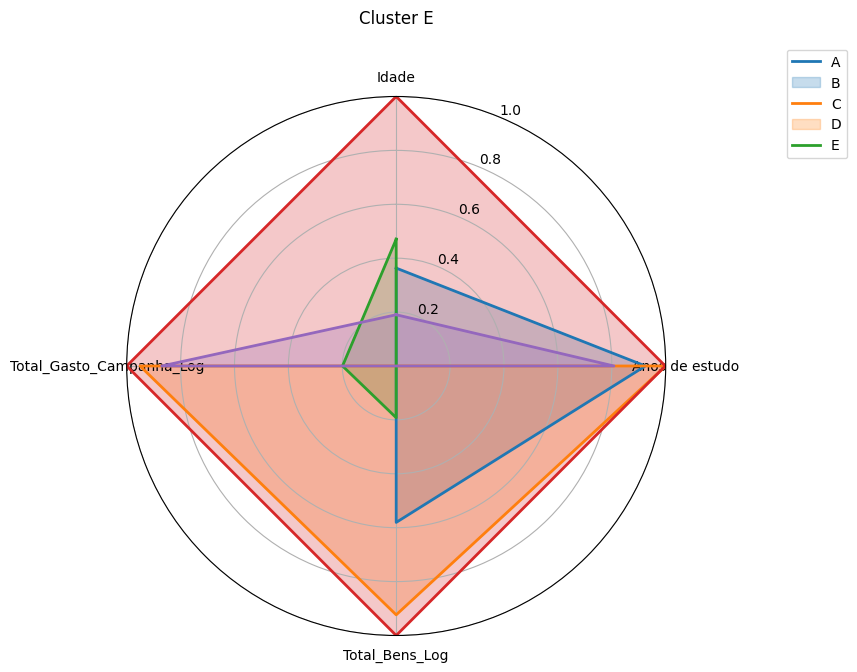

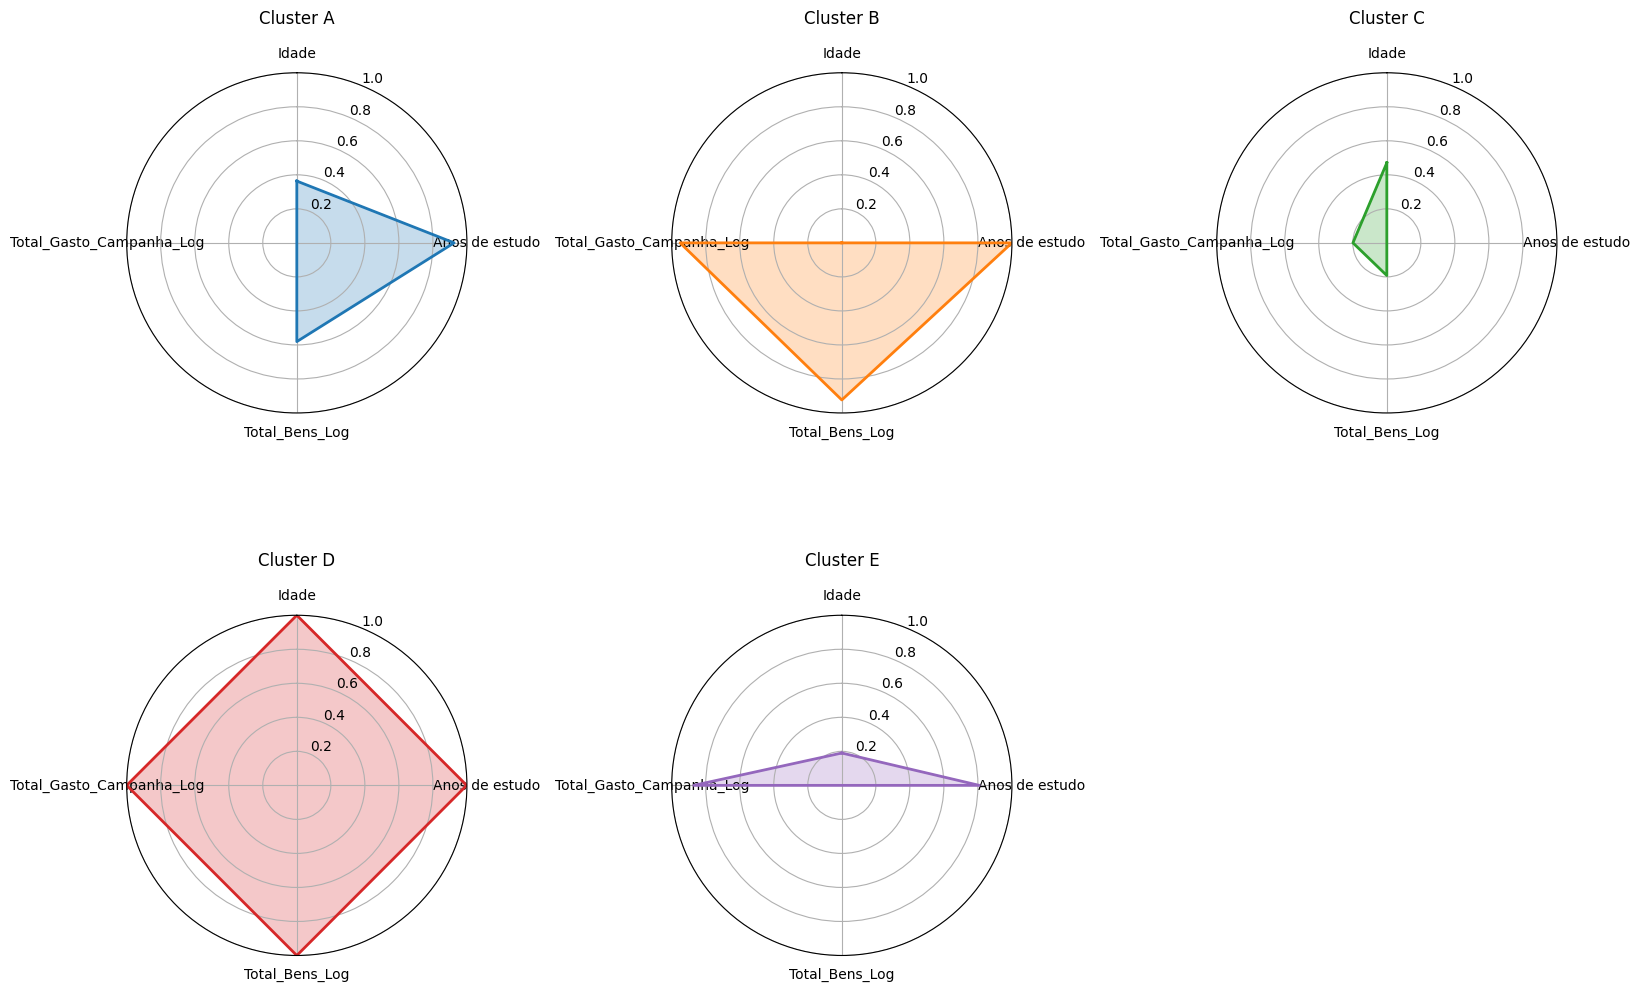

In [10]:
import matplotlib.pyplot as plt
from math import pi
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Dados médios dos clusters
dados_clusters = {
    "A": [47.94, 14.40, 7.89, 0.07],
    "B": [40.49, 14.93, 12.41, 11.05],
    "C": [50.14, 7.90, 2.77, 2.37],
    "D": [61.00, 14.92, 13.42, 11.62],
    "E": [44.39, 13.58, 0.24, 10.12]
}

labels_eixos = ["Idade", "Anos de estudo", "Total_Bens_Log", "Total_Gasto_Campanha_Log"]

# Converte para DataFrame
df_clusters = pd.DataFrame.from_dict(dados_clusters, orient="index", columns=labels_eixos)

# Normalização MinMax (0–1)
scaler = MinMaxScaler()
centros_norm = scaler.fit_transform(df_clusters.values)

# Função para radar chart
def plot_radar(ax, valores, labels_eixos, titulo, cor="blue"):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)

    # Limite fixo 0–1 após normalização
    ax.set_ylim(0, 1)

    valores = list(valores) + [valores[0]]
    ax.plot(angulos, valores, linewidth=2, color=cor)
    ax.fill(angulos, valores, alpha=0.25, color=cor)
    ax.set_title(titulo, y=1.12)

# --- todos os clusters juntos ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (cl, valores) in enumerate(zip(df_clusters.index, centros_norm)):
    plot_radar(ax, valores, labels_eixos, f"Cluster {cl}", cor=plt.cm.tab10(i))
ax.legend(df_clusters.index, loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.show()

# --- um radar por cluster ---
ncols = min(len(df_clusters), 3)
nrows = -(-len(df_clusters) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (cl, valores) in enumerate(zip(df_clusters.index, centros_norm)):
    plot_radar(axes[i], valores, labels_eixos, f"Cluster {cl}", cor=plt.cm.tab10(i))

for j in range(len(df_clusters), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
